# Литературная батарея фич × зрительная кора

Фичи из `docs/FEATURE_BATTERY.md` (каждая с опубликованным источником), посчитанные
`scripts/f7_feature_battery.py`. Три уровня анализа:

1. **скаляры × согласованность зон** — расширение ноутбука 05 с 14 до 21+ цитируемых фич;
2. **семейные RDM × мозговые RDM** — RSA целых пространств (GIST, Портилья–Симончелли,
   цвет, объекты, скалярное низкоуровневое) против каждой зоны;
3. **variance partitioning** — уникальные и общие доли семейств в геометрии каждой зоны:
   главный методический совет обзора (семейства скоррелированы by design натуральных сцен,
   поэтому единственный честный язык — уникальные/общие доли).


In [1]:
import json, sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata, spearmanr

from nsd_rsa.config import load_config, resolve_paths
from nsd_rsa.design import load_expdesign, usable_images
from nsd_rsa.loaders import average_repeats, common_valid_vertices, load_subject
from nsd_rsa.noise_ceiling import normalise_to_ceiling
from nsd_rsa.rdm import compare_rdms, compute_rdm

cfg = load_config(str(ROOT / "configs" / "vlm.yaml"))
paths = resolve_paths(cfg)
design = load_expdesign(paths["meta"] / "nsd_expdesign.mat")
idx = usable_images(cfg["stimuli"]["subjects"], design, cfg["stimuli"]["min_repeats"])
valid = common_valid_vertices(paths["betas"], paths["cache"] / "valid_vertices.npy")
CEIL = {k: v[0] for k, v in json.loads((ROOT / "cache" / "rsa_results.json").read_text())["ceilings"].items()}

ROIS = ["early", "midventral", "ventral", "lateral"]
BRAIN = {}
for p in sorted(paths["betas"].glob("*_shared_betas.h5")):
    d = load_subject(p)
    for roi in ROIS:
        patt, _ = average_repeats(d, images=idx, roi=roi, valid=valid)
        BRAIN.setdefault(roi, {})[d.subject] = compute_rdm(patt.astype(np.float64))
    del d
SUBJECTS = sorted(BRAIN["early"])

SCAL = pd.read_csv(ROOT / "cache" / "feature_battery.csv")
ARR = np.load(ROOT / "cache" / "feature_battery.npz")
CATS = np.load(ROOT / "cache" / "coco_categories.npz")
print(f"{len(idx)} картинок · скаляров: {SCAL.shape[1]} · gist {ARR['gist'].shape} · "
      f"ps {ARR['ps'].shape} · hue {ARR['hue'].shape}")

515 картинок · скаляров: 21 · gist (515, 512) · ps (515, 710) · hue (515, 10)


In [2]:
def rank_sq(c):
    return squareform(rankdata(c))

CONSIST = {}
for roi in ROIS:
    rows = np.stack([rank_sq(BRAIN[roi][s]) for s in SUBJECTS])
    rows = (rows - rows.mean(2, keepdims=True)) / (rows.std(2, keepdims=True) + 1e-12)
    sim = np.einsum("sij,tij->sti", rows, rows) / rows.shape[2]
    CONSIST[roi] = sim[np.triu_indices(len(SUBJECTS), 1)].mean(0)
print("targets ready")

targets ready


## 1. Скаляры батареи × согласованность зон


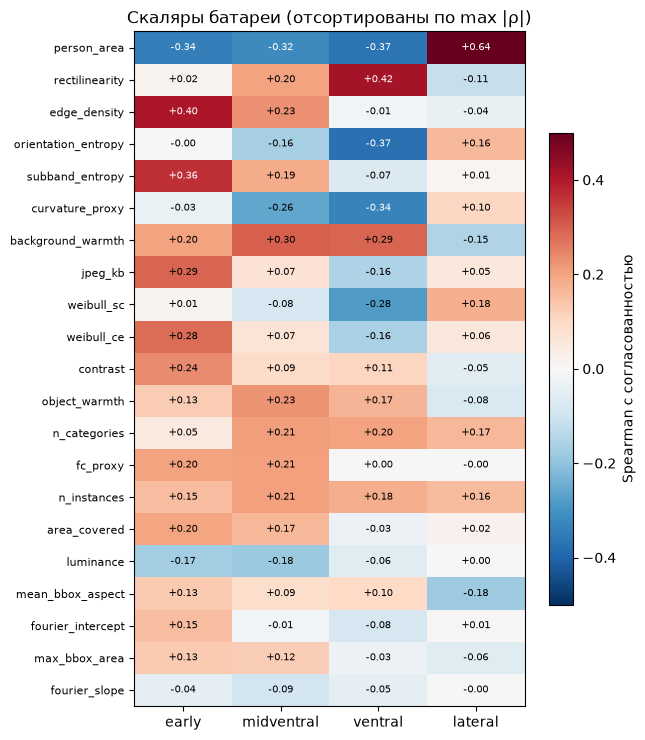

In [3]:
S = SCAL.fillna(SCAL.median(numeric_only=True))
T = pd.DataFrame({roi: {c: spearmanr(S[c], CONSIST[roi]).statistic for c in S.columns}
                  for roi in ROIS})
T = T.reindex(T.abs().max(axis=1).sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(6.5, 7.5))
im = ax.imshow(T.values, cmap="RdBu_r", vmin=-.5, vmax=.5, aspect="auto")
ax.set_xticks(range(len(ROIS))); ax.set_xticklabels(ROIS)
ax.set_yticks(range(len(T))); ax.set_yticklabels(T.index, fontsize=8)
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        ax.text(j, i, f"{T.values[i,j]:+.2f}", ha="center", va="center", fontsize=7,
                color="w" if abs(T.values[i,j]) > .32 else "k")
plt.colorbar(im, shrink=.7, label="Spearman с согласованностью")
ax.set_title("Скаляры батареи (отсортированы по max |ρ|)")
plt.tight_layout(); plt.show()

## 2. Семейные RDM против мозговых

Каждое семейство превращаем в одну RDM (столбцы z-скорим, 1−Pearson; категории — Jaccard)
и меряем RSA с каждой зоной (по испытуемым, нормировка на потолок).


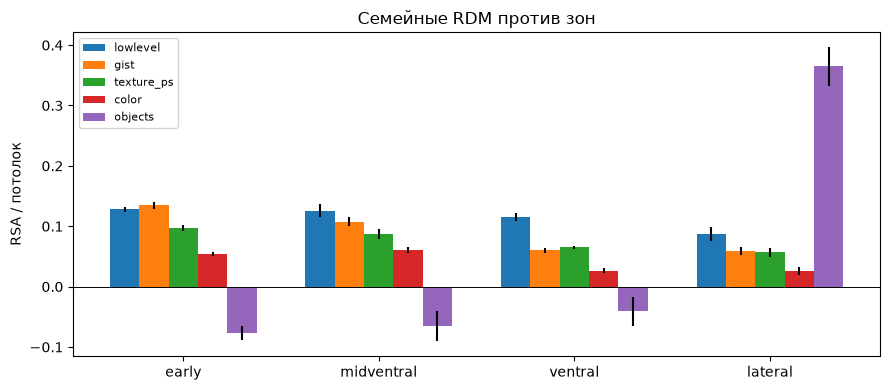

roi,early,midventral,ventral,lateral
family,,,,
color,0.054,0.060,0.026,0.025
gist,0.135,0.108,0.060,0.059
lowlevel,0.128,0.125,0.115,0.087
objects,-0.077,-0.065,-0.041,0.365
texture_ps,0.097,0.087,0.065,0.057


In [4]:
def zrdm(X):
    Z = (X - X.mean(0)) / (X.std(0) + 1e-12)
    return compute_rdm(Z.astype(np.float64))

lowlevel_cols = ["fourier_slope", "fourier_intercept", "weibull_ce", "weibull_sc",
                 "edge_density", "subband_entropy", "jpeg_kb", "fc_proxy",
                 "rectilinearity", "orientation_entropy", "curvature_proxy",
                 "luminance", "contrast"]
FAM = {
    "lowlevel": zrdm(S[lowlevel_cols].values),
    "gist": zrdm(ARR["gist"]),
    "texture_ps": zrdm(ARR["ps"]),
    "color": zrdm(ARR["hue"]),
    "objects": pdist(CATS["multihot"], metric="jaccard"),
}
rows = []
for fam, rdm in FAM.items():
    for roi in ROIS:
        vals = [normalise_to_ceiling(compare_rdms(rdm, BRAIN[roi][s]), CEIL[roi])
                for s in SUBJECTS]
        rows.append({"family": fam, "roi": roi, "rsa": np.mean(vals),
                     "sem": np.std(vals) / np.sqrt(8)})
FR = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
w = 0.15
for k, fam in enumerate(FAM):
    sub = FR[FR.family == fam]
    ax.bar(np.arange(4) + k * w, sub["rsa"].values, w, yerr=sub["sem"].values, label=fam)
ax.set_xticks(np.arange(4) + 2 * w); ax.set_xticklabels(ROIS)
ax.set_ylabel("RSA / потолок"); ax.legend(fontsize=8)
ax.set_title("Семейные RDM против зон"); ax.axhline(0, color="k", lw=.7)
plt.tight_layout(); plt.show()
FR.pivot_table(index="family", columns="roi", values="rsa")[ROIS].round(3)

## 3. Variance partitioning: уникальное и общее

Ранговая регрессия мозговой RDM (среднее по испытуемым) на 5 семейных RDM.
`unique(f)` = R²(все) − R²(без f); `shared` = R²(все) − Σ unique. Это язык, на котором
обзор рекомендует говорить о скоррелированных семействах.


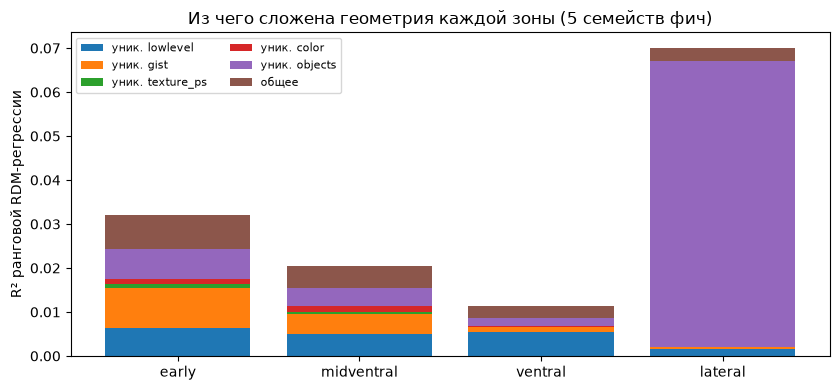

,R2_full,u_lowlevel,u_gist,u_texture_ps,u_color,u_objects,shared
roi,,,,,,,
early,0.032,0.006,0.009,0.001,0.001,0.007,0.008
midventral,0.020,0.005,0.005,0.000,0.001,0.004,0.005
ventral,0.011,0.005,0.001,0.000,0.000,0.002,0.003
lateral,0.070,0.002,0.001,0.000,0.000,0.065,0.003


In [5]:
def r2(y, Xcols):
    X = np.column_stack(Xcols + [np.ones(len(y))])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1 - resid.var() / y.var()

fams = list(FAM)
ranks = {f: rankdata(FAM[f]) for f in fams}
part_rows = []
for roi in ROIS:
    y = rankdata(np.mean([BRAIN[roi][s] for s in SUBJECTS], axis=0))
    full = r2(y, [ranks[f] for f in fams])
    uniq = {f: full - r2(y, [ranks[g] for g in fams if g != f]) for f in fams}
    part_rows.append({"roi": roi, "R2_full": full, **{f"u_{f}": u for f, u in uniq.items()},
                      "shared": full - sum(uniq.values())})
P = pd.DataFrame(part_rows).set_index("roi")
fig, ax = plt.subplots(figsize=(8.5, 4))
bottom = np.zeros(len(ROIS))
for col, lab in [(f"u_{f}", f"уник. {f}") for f in fams] + [("shared", "общее")]:
    ax.bar(ROIS, P[col], bottom=bottom, label=lab)
    bottom += P[col].values
ax.set_ylabel("R² ранговой RDM-регрессии")
ax.set_title("Из чего сложена геометрия каждой зоны (5 семейств фич)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
P.round(3)

## Как читать

- **§1** — какие отдельные цитируемые фичи маркируют согласованность каждой зоны
  (сравнить с ноутбуком 05: воспроизвелись ли edge/entropy у early при том, что фич
  стало больше и они каноничнее).
- **§2** — какое *пространство* ближе к геометрии зоны: у early ожидаем gist/PS/lowlevel,
  у lateral — objects; интересен разрыв ventral между texture_ps и objects
  (Henderson 2023 предсказывает заметный вклад PS и в высоких зонах).
- **§3** — сколько у каждого семейства уникального: если у objects в lateral большая
  уникальная доля при малой у низкоуровневых — это ещё один способ сказать, что
  латеральная геометрия семантична; большая общая доля — нормально для натуральных
  сцен и именно поэтому нужны частичные методы.

Дальше (ярус 2 из FEATURE_BATTERY.md): THINGSplus-нормы animacy/size на категории COCO,
memorability через ResMem — с ними §1–3 повторяются бесплатно.
